In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [66]:
data=pd.read_csv('creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [67]:
data = data.fillna(data.mean(numeric_only=True))

In [68]:
data["hour"] = (data["Time"] // 3600) % 24

In [69]:
X=data.drop(columns=['Class','Time'],axis=1)
Y=data["Class"]

In [70]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_scale=scale.fit_transform(X)

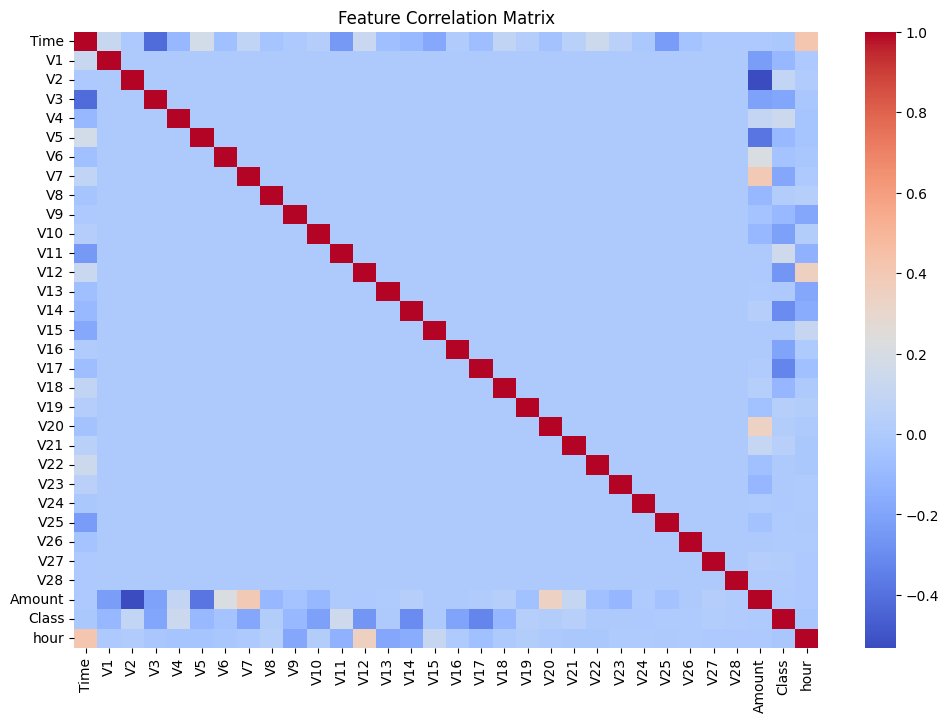

In [71]:
#EDA
corr = data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [72]:
from sklearn.decomposition import PCA
pca=PCA()
X_pca=pca.fit_transform(X_scale)

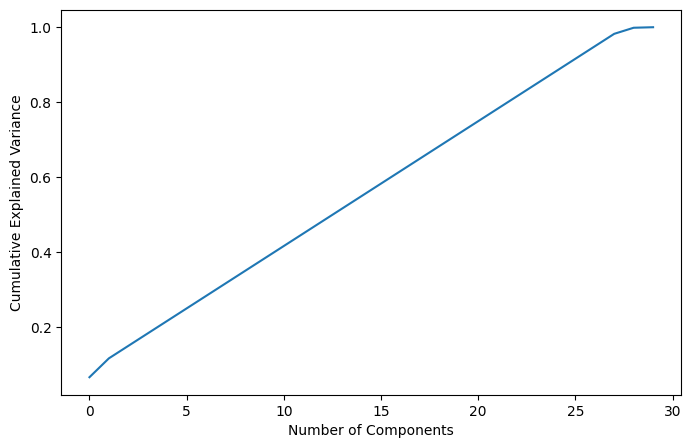

In [73]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [74]:
pca=PCA(n_components=0.95)
X_pca=pca.fit_transform(X_scale)

In [75]:
X_pca=pd.DataFrame(X_pca)
X_pca

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.354824,-1.512895,0.188281,0.000086,-0.225684,-0.034203,0.311505,0.508260,-0.179634,0.635024,...,0.685726,-0.124052,0.051290,0.107670,0.721574,0.450770,0.386615,0.998131,-0.101467,-1.181262
1,-0.442472,-1.402702,-0.099286,-0.180557,-0.979320,-0.164361,-0.019239,1.070886,0.309071,0.290491,...,-0.731334,-0.387576,0.312717,-0.318870,-0.392624,0.542096,-0.133779,-0.358898,-0.573644,1.067066
2,1.805375,-1.438825,1.135767,0.760957,-0.107091,-1.617081,0.709027,2.240184,0.901758,-0.251226,...,-0.235807,1.505978,1.057318,-0.487780,2.211783,1.566912,0.763634,0.913199,-0.089342,0.620612
3,0.275674,-1.443357,1.426706,2.410762,-0.345422,-1.183697,1.202905,-0.434329,-0.521237,-1.428115,...,-1.472887,-0.150368,0.186079,0.192008,0.179572,1.255149,-0.353753,-0.375565,0.806634,0.421324
4,-0.034456,-1.543189,0.516370,-0.123726,0.673193,0.397789,0.606706,-0.456641,-0.093248,-0.141004,...,1.265573,-0.239032,0.258938,0.801947,-0.081346,-0.317581,0.504019,1.770500,-0.992470,1.271743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-1.451586,1.918508,-2.281599,0.322103,0.285155,1.979136,2.443565,-3.105181,0.764338,4.144766,...,0.865687,3.292869,-6.906756,-1.950398,-9.631561,0.674946,1.747784,0.346438,4.597366,1.152392
284803,-0.350601,1.274645,0.280875,-0.174494,1.033486,-2.227344,-0.198332,1.403269,-0.366283,0.088043,...,-0.425868,1.223082,0.809840,-0.356284,1.329252,0.242166,0.145084,0.046624,-0.915945,1.534791
284804,-0.140233,1.188670,0.140680,0.337036,-0.539025,-0.238321,-0.561302,2.019951,-0.482704,-0.204398,...,-0.021067,1.962102,-0.237185,-0.552553,0.608443,-1.398603,0.371607,1.059805,1.305846,-0.043422
284805,-0.439267,1.362460,0.636130,-0.386012,0.960068,0.574317,1.391483,0.191585,-0.458052,0.305532,...,2.242667,-1.747765,0.174651,-0.378096,-0.283762,-1.408860,0.160388,2.577568,0.847058,-1.632960


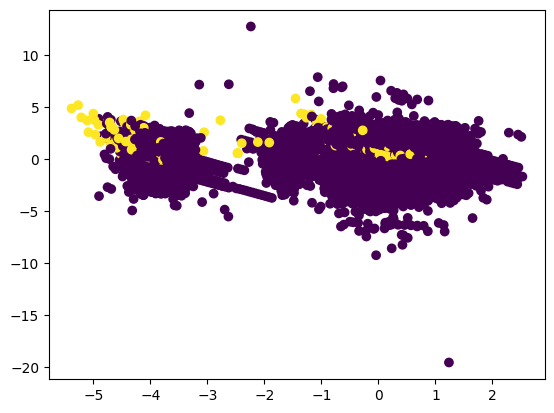

In [78]:
plt.scatter(x=X_pca.iloc[:, 1], y=X_pca.iloc[:, 3], c=Y)

In [79]:
#Clustering
from sklearn.cluster import KMeans
sse=[]
for i in range(2,21):
  model=KMeans(n_clusters=i)
  model.fit_predict(X_pca)
  sse.append(model.inertia_)

In [80]:
!pip install Kneed

In [86]:
from kneed import KneeLocator
knee=KneeLocator(x=range(2,21),y=sse,curve="convex",direction="decreasing")
print("K=",knee.elbow)

K= 15


In [87]:
sse

[8136837.266300955,
 7845766.487887354,
 7591909.550261294,
 7376238.615491125,
 7146849.042443828,
 7019566.319182541,
 6890232.024267497,
 6622579.810319611,
 6580501.979432346,
 6323619.486063454,
 6195581.234464257,
 6009565.573196938,
 5986660.628131476,
 5805083.1255607875,
 5856720.487836663,
 5668281.8603978995,
 5594049.486488344,
 5502328.315168808,
 5359329.407932934]

Text(0.5, 1.0, 'Elbow k Diagram')

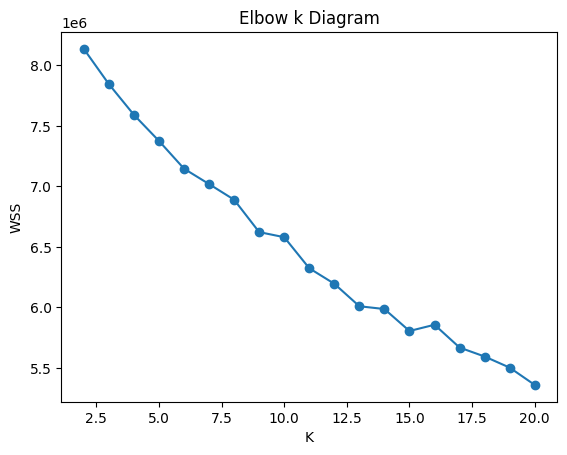

In [82]:
# K value by Elbow Knee method
plt.plot(range(2,21), sse, marker='o')
plt.xlabel("K")
plt.ylabel("WSS")
plt.title("Elbow k Diagram")


In [84]:
#Start Clusturing by Kmeans Method
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=10,random_state=42)
clusters=kmeans.fit_predict(X_pca)
data["cluster"] = clusters

In [85]:
data["cluster"]

,cluster
0,0
1,2
2,0
3,0
4,1
...,...
284802,8
284803,1
284804,5
284805,2


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_pca)

plt.scatter(X_vis[:,0], X_vis[:,1], c=clusters)
plt.title("KMeans Clusters")
plt.show()

In [ ]:
data["amount_per_hour"] = data["Amount"] / (data["hour"] + 1)

In [ ]:
data.drop(columns=['Amount','hour'],axis=1)

In [ ]:
X=data.drop(columns=['cluster','Class'])
y=data['cluster']

In [ ]:
#train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state=0)

In [ ]:
#Model Train
#Random Forest
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print("Accuracy=",acc)
print("Precission=",precision_score(y_test,y_pred, average='weighted'))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))

In [ ]:
#Stacking
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [83]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('svm', SVC(probability=True)),
    ('xgb', XGBClassifier())
]
stack_model=StackingClassifier(
    estimators=estimators,final_estimator=LogisticRegression()
)
stack_model.fit(X_train,y_train)
y_pred=stack_model.predict(X_test)
print("Accuracy=",accuracy_score(y_test,y_pred))

Accuracy= 0.9791666666666666


Design DL Model

In [97]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
import torch.optim as optim


In [91]:
X_train_tensor=torch.tensor(X_train.values,dtype=torch.float32)
X_test_set=torch.tensor(X_test.values,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.long)

In [93]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_load = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_set, y_test_tensor)
test_load = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [95]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()
    self.model=nn.Sequential(
        #Ip layer
        nn.Linear(X.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 7)
    )
  def forward(self,x):
    return self.model(x)

In [102]:
model = ANN()

# loss & optim
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [101]:
# Training the NN

epochs = 100
for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for xb, yb in train_load:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criteria(outputs, yb)
        loss.backward()
        optimizer.step() # params update

        running_loss += loss.item()

    train_loss = running_loss / len(train_load)

    print(f"epoch = {e+1}/{epochs}, loss = {train_loss}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x32 and 30x64)

In [ ]:
# Evaluate
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_load:
        outputs = model(xb) # [0.2, 0.5, 1.3, -0.5, ..] - 7 vals
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == yb).sum().item()
        total += yb.size(0) # actual samples in each batch

print("accuracy: ", correct/total * 100)